Dataset is about houses selling rate in Ames, Iowa between 2006 and 2010. Each row is a sold house and each column is a feature. Features describe everything about house and the column SelePrice is a price for transaction. My objective is predict price of new house based on the new estate's features.

In [1]:
import pandas as pd
from src.data_loader import data_loader

houses_raw = data_loader()

In [2]:
houses_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

We can see that we have in dataset null values. Now I am sure that I have to do with it something. I have three options:
1.  Drop columns with null values.
2.  Drop the rows with null values.
3.  Imput data with special sckit-learn method.

In [3]:
null_value = houses_raw.isnull().sum()
null_value = null_value[null_value > 0].sort_values(ascending=False)
null_value

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

We see which colums have null values. From previous info() function I know that most of them are string values. I have to know what null means.

In [4]:
houses_raw.sample(15)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1372,1373,60,RL,75.0,9750,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,274300
339,340,20,RL,66.0,12400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,155000
1157,1158,120,RL,34.0,5001,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,230000
627,628,80,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,153000
210,211,30,RL,67.0,5604,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,98000
405,406,20,RL,NaN,9991,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,6,2009,WD,Normal,150000
866,867,20,RL,67.0,10656,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2007,New,Partial,248900
63,64,70,RM,50.0,10300,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,GdPrv,NaN,0,4,2010,WD,Normal,140000
1000,1001,20,RL,74.0,10206,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,82000
961,962,60,RL,NaN,12227,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,272000


We know from description that null does not mean lack of value. For expample:
- PoolArea - NA means lack od pool,
- MiscFeature - NA means none,
- Alley - NA means no alley access,
- Fence - NA means no fence,
- MasVnrType - NA means none,
- FireplaceQu - NA means none,
- LotFrontage - lack of description,
- GarageType - NA means no garage,
- GarageFinish - NA means no garage,
- GarageYrBlt - NA means no garage.

We see corelation between garage features. Probably I will connect Na value into one feature or do something with it. Now I will see LotFrontage column's values.

In [5]:
lotFrontageColumn = pd.Series(houses_raw['LotFrontage'])
lotFrontageColumn.sample(10)

262     88.0
1250    93.0
391     71.0
1214    69.0
1458    68.0
1011    75.0
420     78.0
888     95.0
1369    48.0
1021    64.0
Name: LotFrontage, dtype: float64

From description we know that value represent linear feet of street connectecd to property. I assume that NA value means lack of measurement of conection, becasue every property has to have access to any street. Propaby I will imput minimal value from the feature to NA value.

In [6]:
lotFrontageColumn.min()

np.float64(21.0)

Now I'm going to do some plots to visualize data.

1) Histplot of Sale Prices

<Axes: >

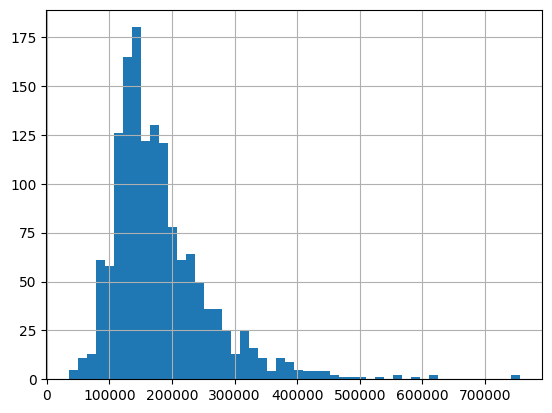

In [7]:
houses_raw['SalePrice'].hist(bins=50)

I see heavy tail distribution. Propably I will use log function to achive Gauss's distributin which is needed to proper work of ML functions.

2) Correlations with 'SalePrice'

<Axes: ylabel='None'>

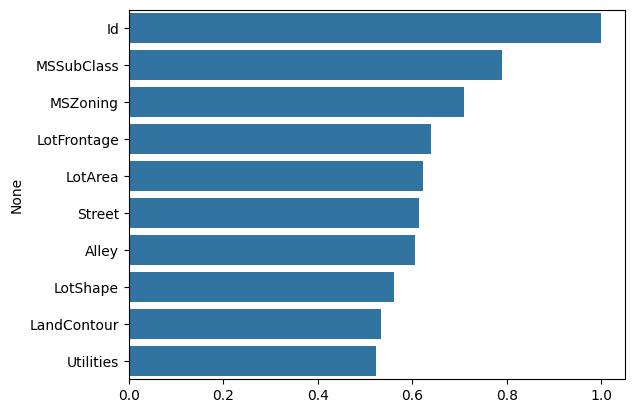

In [8]:
import seaborn as sns

corr_matrix = houses_raw.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_raw.columns[:10])

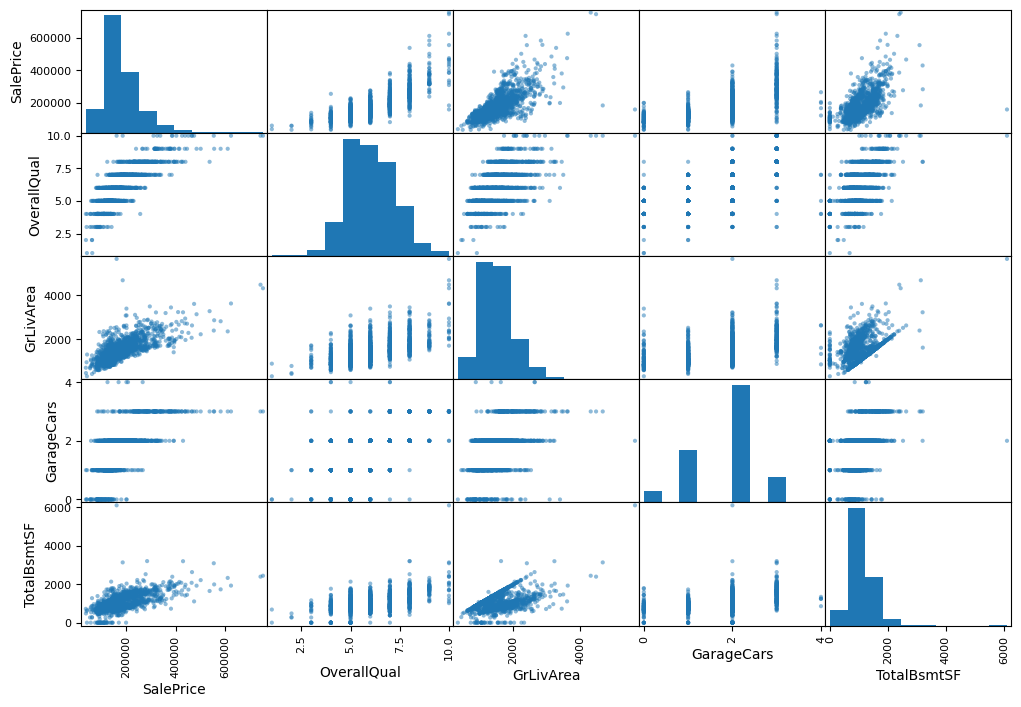

In [9]:
from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix

attributes = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars','TotalBsmtSF']
scatter_matrix(houses_raw[attributes], figsize=(12, 8))
plt.show()

In [19]:
attributes2 = ['SalePrice', '1stFlrSF', 'FullBath', 'YearBuilt', 'TotRmsAbvGrd']

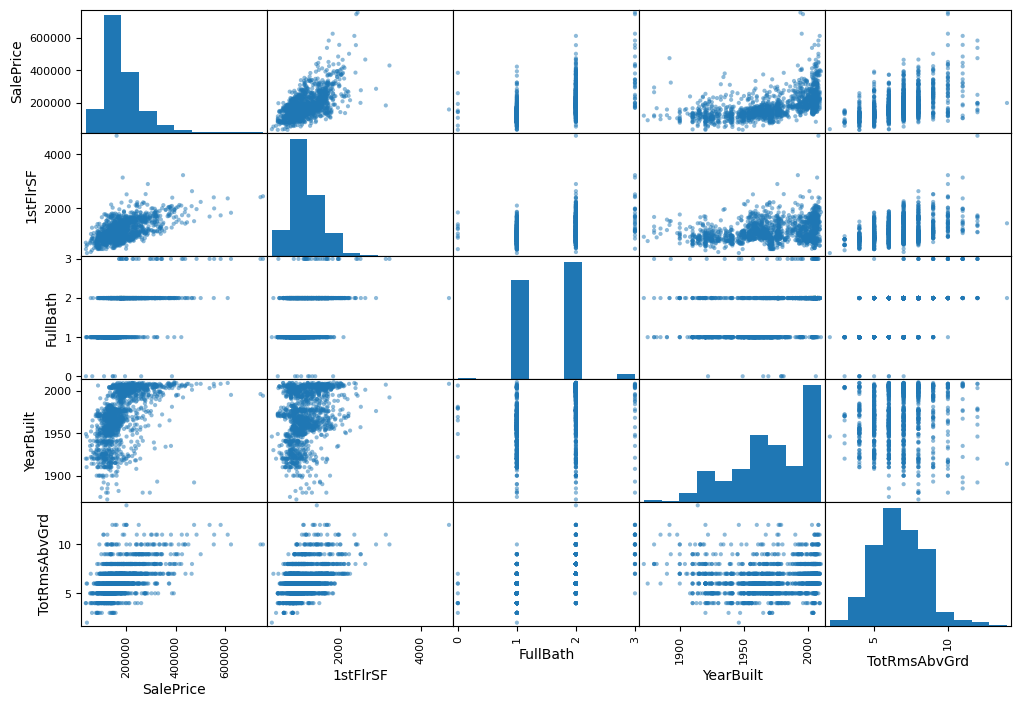

In [20]:
scatter_matrix(houses_raw[attributes2], figsize=(12, 8))
plt.show()

I see which dependencies are the most perspective. I chosen three the best candidates for prediction estate's price.

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

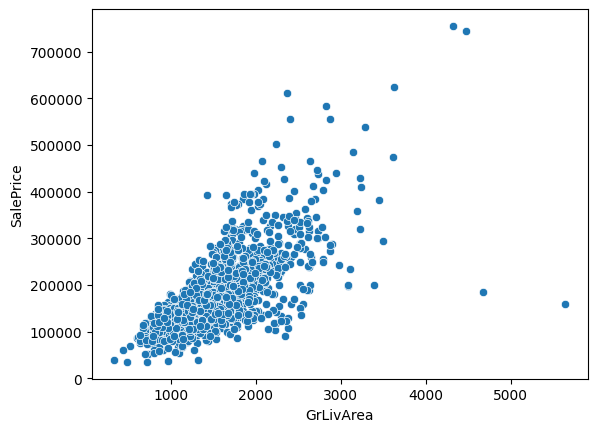

In [12]:
# GrLivArea

sns.scatterplot(x='GrLivArea', y='SalePrice', data=houses_raw)

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

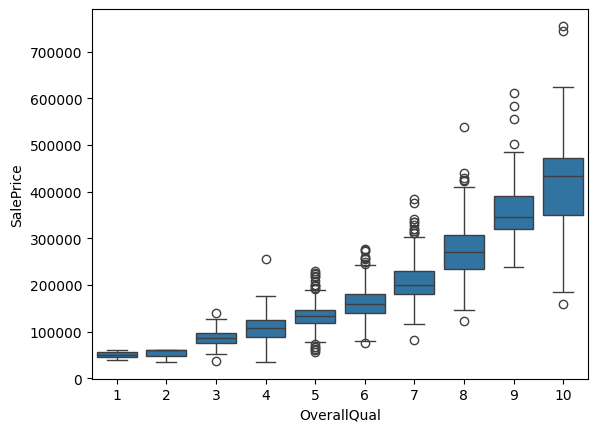

In [13]:
# OverallQual

sns.boxplot(x='OverallQual', y='SalePrice', data=houses_raw)

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

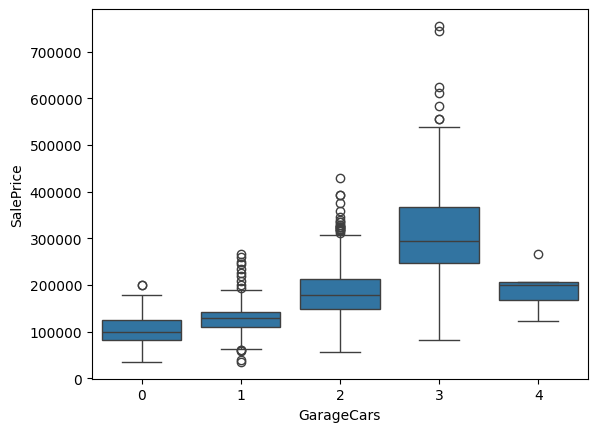

In [14]:
# GarageCars

sns.boxplot(x='GarageCars', y='SalePrice', data=houses_raw)

We see strong correlation between three features and price. Especially OverallQual and GrLivArea have strong rising tendenction in order to price.

3) Na values

<Axes: ylabel='None'>

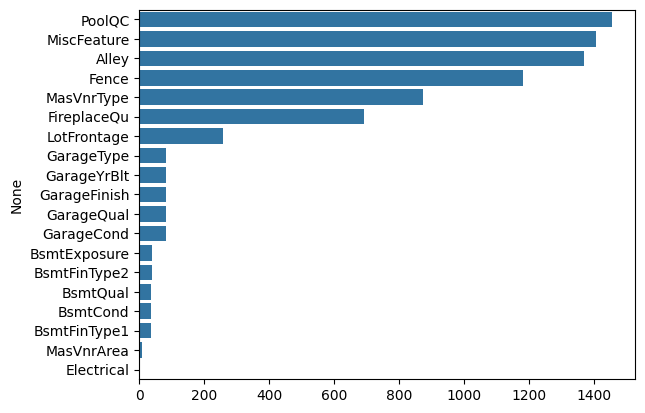

In [15]:
null_df = houses_raw.isnull().sum()
null_df = null_df[null_df > 0].sort_values(ascending=False)
sns.barplot(x=null_df.values, y=null_df.index)

4) Heatmap of correlation

<Axes: >

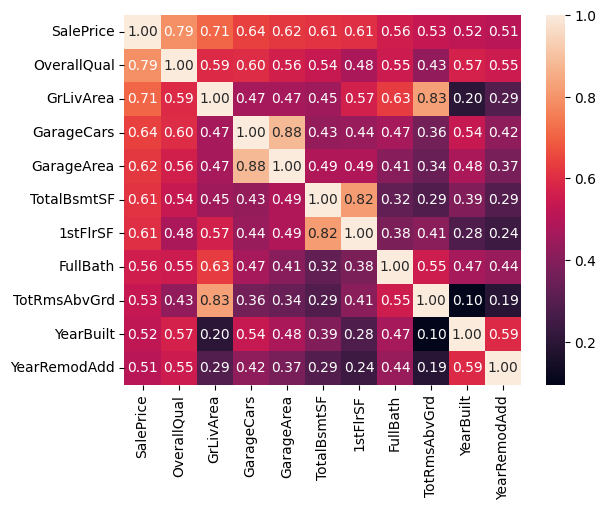

In [16]:
top_features = corr_matrix.index[:11]
sns.heatmap(houses_raw[top_features].corr(), annot=True, fmt=".2f")